# Variant scoring and in silico mutagenesis for oncogenic TAL1 insertion

This notebook fully reproduces panels b and e of Figure 6 in "Advancing regulatory variant effect prediction with AlphaGenome" (Avsec et al. 2026) using `alphagenome-pytorch` and compares the resulting figures to predictions generated using the DeepMind JAX checkpoint. We score the oncogenic insertion `chr1:47239296:C>ACG` in CD34+ Common Myeloid Progenitors (CMP) tracks. This reproduction includes:

- **Figure 6b**: Predicted difference for ALT–REF in tracks of CD34+ CMPs
- **Figure 6e**: In-silico mutagenesis (ISM) sequence logos on REF and ALT backgrounds

## Setup

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']   = 'platform'

import jax
import jax.numpy as jnp
import logomaker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import torch
from tqdm import tqdm
from safetensors.torch import load_file
import gc

from alphagenome_research.model import dna_model as _jax_dna_model
from alphagenome_research.model.metadata import metadata as _jax_metadata_lib
from alphagenome_research.model.variant_scoring.center_mask import (
    create_center_mask,
    _apply_aggregation,
)
from alphagenome_research.model.variant_scoring.gene_mask import (
    _score_gene_variant,
)
from alphagenome_research.model.variant_scoring.gene_mask_extractor import (
    GeneMaskExtractor,
    GeneMaskType,
)
from alphagenome.models import dna_output as _jax_dna_output
from alphagenome.data import genome as jax_genome
from alphagenome.data import track_data as jax_track_data
from alphagenome.visualization import plot_components
from alphagenome.models import variant_scorers as jax_variant_scorers

from alphagenome_pytorch.model import AlphaGenome
from alphagenome_pytorch.config import DtypePolicy
from alphagenome_pytorch.variant_scoring import (
    VariantScoringModel,
    Variant,
    Interval,
    CenterMaskScorer,
    OutputType,
    AggregationType,
    visualize_variant,
)
from alphagenome_pytorch.variant_scoring.visualization_utils import (
    extract_predictions,
    pytorch_to_track_data,
    get_transcript_extractors,
    extract_ism_logo,
    build_ism_logos,
    plot_ism_logos
)
from alphagenome_pytorch.variant_scoring.scorers import GeneMaskLFCScorer
from alphagenome_pytorch.variant_scoring.sequence import apply_variant_to_sequence

Define local paths to the JAX and PyTorch `all-folds` checkpoints (downloaded from kaggle and HuggingFace, respectively). Also define paths to gencode annotations and the reference.

In [2]:
BASE_DIR = Path("/scratch/m000097/abuen/personal/alphagenome-pytorch/ckpts")
TORCH_CKPT_PATH = BASE_DIR / 'torch' / 'model_all_folds.safetensors'
JAX_CKPT_PATH = BASE_DIR / 'jax' / 'all_folds' / '1'

FASTA_PATH = BASE_DIR / 'resources' / 'hg38.fa'
GTF_PATH = BASE_DIR / 'resources' / 'gencode.46.annotation.parquet'
POLYA_PATH = BASE_DIR / 'resources' / 'gencode.v46.polyAs.linked.parquet'
METADATA_PATH = BASE_DIR / 'resources' / 'track_metadata.parquet'

model = AlphaGenome(num_organisms=2, dtype_policy=DtypePolicy.full_float32())
state_dict = load_file(TORCH_CKPT_PATH, device='cpu')
model.load_state_dict(state_dict, strict=False)
model.cuda().eval()

scoring_model = VariantScoringModel(
    model,
    fasta_path=FASTA_PATH,
    gtf_path=GTF_PATH,
    polya_path=POLYA_PATH,
    default_organism='human',
)
scoring_model.load_all_metadata(METADATA_PATH)
print('Variant scoring model loaded')

Variant scoring model loaded


In [3]:
# Oncogenic insertion 
variant = Variant.from_str('chr1:47239296:C>ACG')
interval = Interval.centered_on('chr1', 47239296, width='1MB')
jax_interval = jax_genome.Interval(interval.chromosome, interval.start, interval.end)
jax_variant = jax_genome.Variant(
    chromosome=variant.chromosome,
    position=variant.position,
    reference_bases=variant.reference_bases,
    alternate_bases=variant.alternate_bases
)
tal1_interval = jax_genome.Interval('chr1', 47209255, 47242023)

# CD34+ CMP biosample
CMP_ONTOLOGY = 'CL:0001059'

print(f'Variant: {variant}')
print(f'Interval: {interval} ({interval.width:,} bp)')

Variant: chr1:47239296:C>ACG
Interval: chr1:46715008-47763584 (1,048,576 bp)


## Figure 6b: ALT–REF prediction differences in CD34+ CMP tracks

We run inference on AlphaGenome for ALT and REF sequences of the oncogenic insertion in CD34+ CMP tracks. Define utilities to extract out predictions for PyTorch and JAX:

In [4]:
def get_torch_diff_track(output_type, label, preferred_res=None):
    """Get ontology + nonpositive-strand filtered ALT-REF diff TrackData."""
    ref_preds, res = extract_predictions(ref_outputs, output_type, preferred_resolution=preferred_res)
    alt_preds, _ = extract_predictions(alt_outputs, output_type, preferred_resolution=preferred_res)
    if ref_preds is None:
        return None

    metadata_list = all_metadata.get(output_type, [])
    # Filter by CMP ontology
    indices = [i for i, m in enumerate(metadata_list) if m.ontology_curie == CMP_ONTOLOGY]
    if not indices:
        return None
    metadata_list = [metadata_list[i] for i in indices]
    ref_preds = ref_preds[:, :, indices]
    alt_preds = alt_preds[:, :, indices]

    # Filter to nonpositive strand (keep '-' and '.', matching JAX filter_to_nonpositive_strand)
    strand_idx = [i for i, m in enumerate(metadata_list) if m.track_strand != '+']
    if not strand_idx:
        return None
    metadata_list = [metadata_list[i] for i in strand_idx]
    ref_preds = ref_preds[:, :, strand_idx]
    alt_preds = alt_preds[:, :, strand_idx]

    ref_td = pytorch_to_track_data(ref_preds, metadata_list, interval, res, label)
    alt_td = pytorch_to_track_data(alt_preds, metadata_list, interval, res, label)

    return jax_track_data.TrackData(
        values=alt_td.values - ref_td.values,
        metadata=ref_td.metadata,
        resolution=ref_td.resolution,
        interval=ref_td.interval,
    )

def get_jax_diff_track(output_type, label):
    """ALT-REF diff TrackData filtered to CMP ontology + nonpositive strand."""
    meta_key, res = _JAX_OUTPUT_CFGS[output_type]
    meta_df = getattr(jax_ag_meta, meta_key).copy()

    # CMP ontology filter
    cmp_mask = (meta_df['ontology_curie'] == CMP_ONTOLOGY).values
    if not cmp_mask.any():
        return None

    # Nonpositive-strand filter: keep '-' and '.', drop '+'
    if 'strand' in meta_df.columns:
        strand_mask = (meta_df['strand'] != '+').values
        mask = cmp_mask & strand_mask
    else:
        mask = cmp_mask
    if not mask.any():
        return None

    ref_pred = np.array(jax_ref_preds[output_type])[0]   # (tracks, seq_len)
    alt_pred = np.array(jax_alt_preds[output_type])[0]
    
    ref_pred = np.array(jax_ref_preds[output_type])[0]   # (seq_len, tracks)
    alt_pred = np.array(jax_alt_preds[output_type])[0]
    
    # filter tracks
    ref_arr = ref_pred[:, mask]     # (seq_len, n_tracks)
    alt_arr = alt_pred[:, mask]
    diff_arr = alt_arr - ref_arr    # (seq_len, n)

    return jax_track_data.TrackData(
        values=diff_arr,
        metadata=meta_df[mask].reset_index(drop=True),
        resolution=res,
        interval=jax_interval,
    )

def _jax_predict(one_hot):
    return jax_ag_model._predict(
        jax_ag_model._params, jax_ag_model._state,
        jax.device_put(one_hot),
        _jax_organism_idx,
        negative_strand_mask=_jax_neg_strand_mask,
        strand_reindexing=_jax_strand_reindex,
    )

Run inference for the PyTorch model using the defined variant scoring model:

In [5]:
# Get raw predictions
ref_outputs, alt_outputs = scoring_model.predict_variant(interval, variant, to_cpu=True)
all_metadata = scoring_model.get_track_metadata()

# Gene annotation
_, longest_extractor = get_transcript_extractors(scoring_model, 'human')

# Compute diff tracks (1bp for RNA-seq/DNase, 128bp for ChIP-histone)
rna_diff = get_torch_diff_track(OutputType.RNA_SEQ, 'RNA-seq', preferred_res=1)
dnase_diff = get_torch_diff_track(OutputType.DNASE, 'DNase', preferred_res=1)
chip_diff = get_torch_diff_track(OutputType.CHIP_HISTONE, 'ChIP-histone')

/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/alphagenome/data/transcript.py:662: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')
/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/alphagenome/data/transcript.py:662: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')


Run inference using the JAX DeepMind checkpoint: 

In [6]:
# Load JAX model
_jax_organism  = _jax_dna_model.Organism.HOMO_SAPIENS
jax_ag_model   = _jax_dna_model.create(checkpoint_path=JAX_CKPT_PATH, device=jax.devices()[0])
jax_ag_meta    = _jax_metadata_lib.load(_jax_organism)
print('JAX checkpoint loaded')

# Reuse scoring_model's fasta extractor (same hg38.fa) to get the sequence string
ref_seq_str = scoring_model.get_sequence(interval)
alt_seq_str = apply_variant_to_sequence(ref_seq_str, variant, interval)[:interval.width]

_encoder    = jax_ag_model._one_hot_encoder
ref_one_hot = _encoder.encode(ref_seq_str)[np.newaxis]   # (1, S, 4)
alt_one_hot = _encoder.encode(alt_seq_str)[np.newaxis]   # (1, S, 4)
_jax_track_meta      = jax_ag_model._metadata[_jax_organism]
_jax_organism_idx    = jnp.array([0], dtype=jnp.int32)
_jax_strand_reindex  = jax.device_put(_jax_track_meta.strand_reindexing)
_jax_neg_strand_mask = jnp.array([False], dtype=bool)

print('Running JAX REF prediction...')
jax_ref_preds = _jax_predict(ref_one_hot)
print('Running JAX ALT prediction...')
jax_alt_preds = _jax_predict(alt_one_hot)
print('JAX predictions complete.')

_JAX_OUTPUT_CFGS = {
    _jax_dna_output.OutputType.RNA_SEQ:      ('rna_seq',      1),
    _jax_dna_output.OutputType.DNASE:        ('dnase',        1),
    _jax_dna_output.OutputType.CHIP_HISTONE: ('chip_histone', 128),
}
jax_rna_diff   = get_jax_diff_track(_jax_dna_output.OutputType.RNA_SEQ,      'RNA-seq')
jax_dnase_diff = get_jax_diff_track(_jax_dna_output.OutputType.DNASE,        'DNase')
jax_chip_diff  = get_jax_diff_track(_jax_dna_output.OutputType.CHIP_HISTONE, 'ChIP-histone')

/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


JAX checkpoint loaded
Running JAX REF prediction...
Running JAX ALT prediction...
JAX predictions complete.


Using the predicted tracks, we overlay the JAX and PyTorch predictions to replicate Figure 6b.

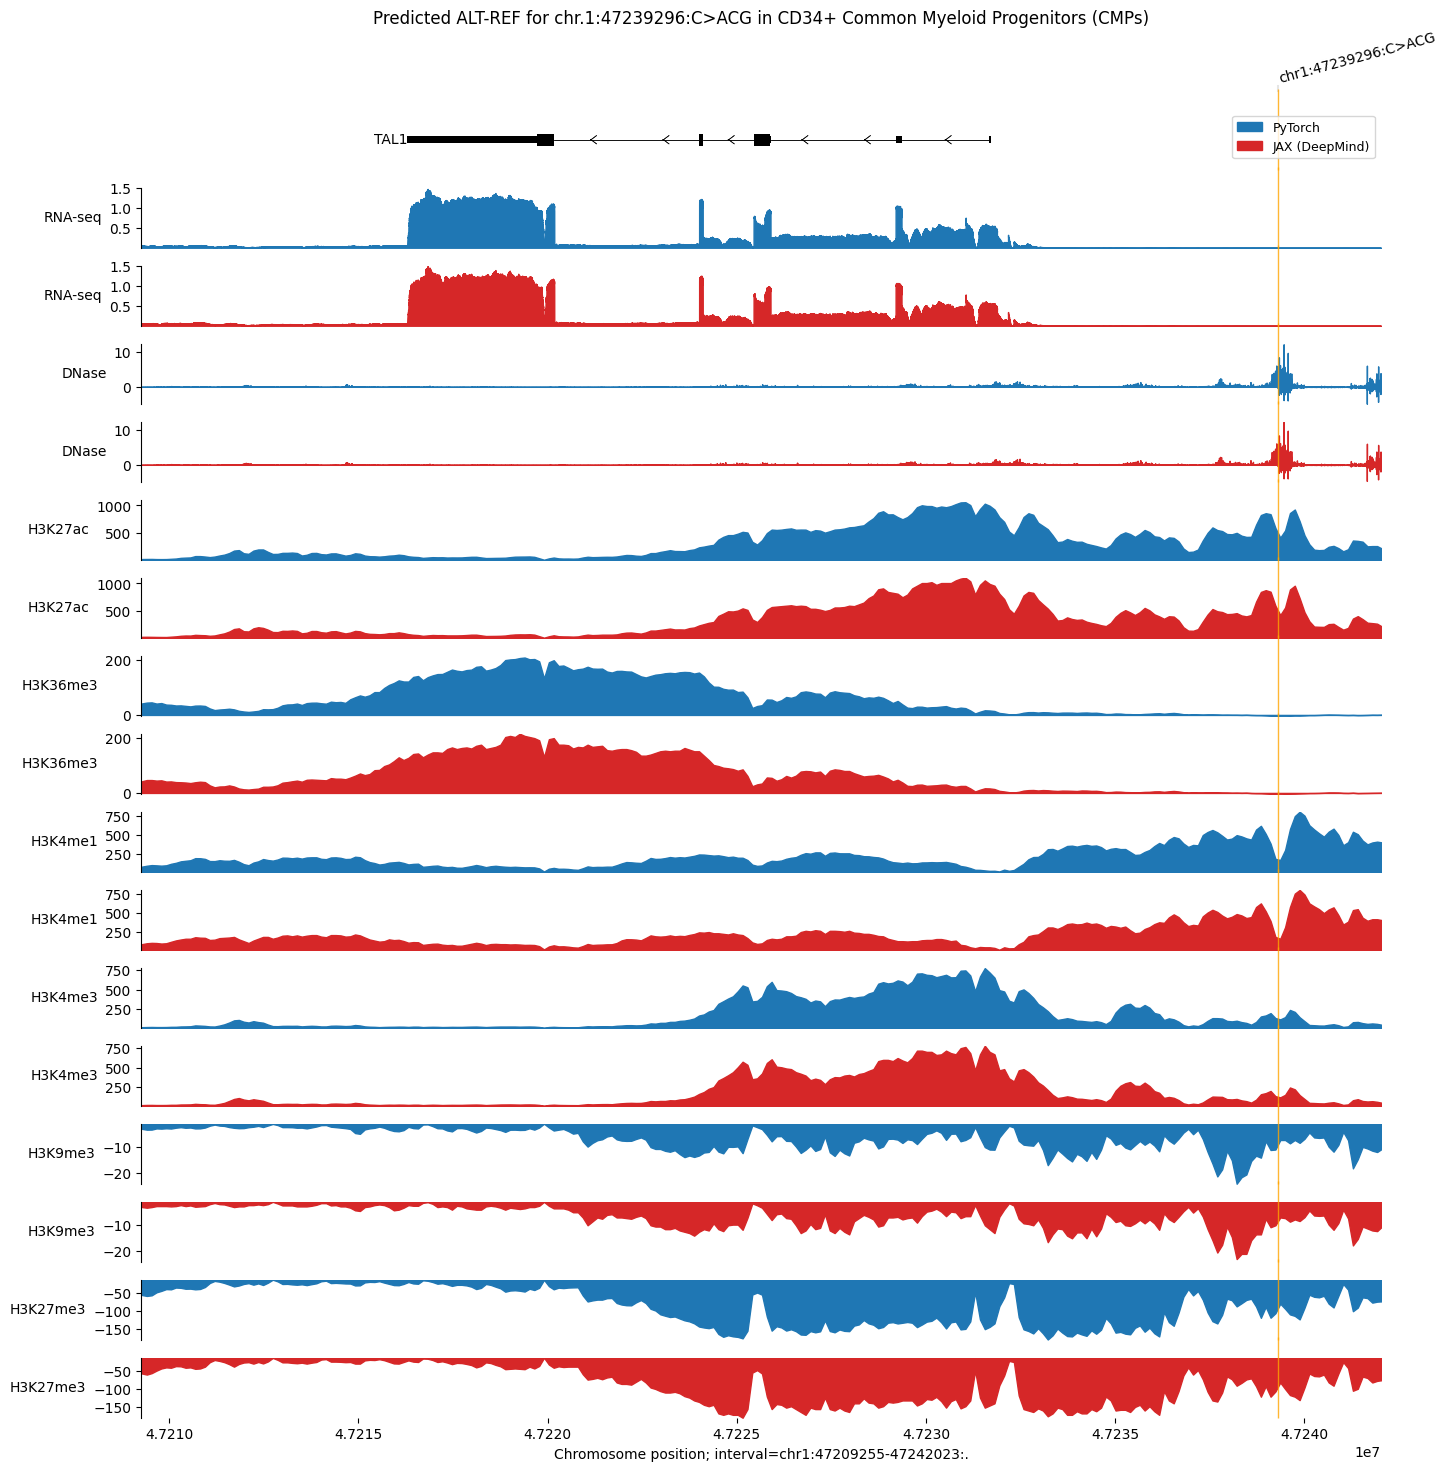

In [7]:
TORCH_COLOR = '#1f77b4'   # blue
JAX_COLOR   = '#d62728'   # red

def merge_with_colors(torch_td, jax_td):
    """Concatenate two TrackDatas along the track axis; return (merged_td, color_list).
    Track names are suffixed to avoid (name, strand) duplicate validation errors.
    """
    if torch_td is None and jax_td is None:
        return None, []
    if torch_td is None:
        return jax_td, [JAX_COLOR] * jax_td.values.shape[1]
    if jax_td is None:
        return torch_td, [TORCH_COLOR] * torch_td.values.shape[1]

    n_torch = torch_td.values.shape[1]
    n_jax   = jax_td.values.shape[1]

    torch_meta = torch_td.metadata.copy()
    jax_meta   = jax_td.metadata.copy()
    torch_meta['name'] = torch_meta['name'] + ' (PyTorch)'
    jax_meta['name']   = jax_meta['name']   + ' (JAX)'

    merged_td = jax_track_data.TrackData(
        values=np.concatenate([torch_td.values, jax_td.values], axis=1),
        metadata=pd.concat([torch_meta, jax_meta], ignore_index=True),
        resolution=torch_td.resolution,
        interval=torch_td.interval,
    )
    return merged_td, [TORCH_COLOR] * n_torch + [JAX_COLOR] * n_jax


# Build components
components = [plot_components.TranscriptAnnotation(longest_extractor.extract(jax_interval))]
merged_rna, rna_colors = merge_with_colors(rna_diff, jax_rna_diff)
components.append(plot_components.Tracks(
    tdata=merged_rna, ylabel_template='RNA-seq',
    shared_y_scale=True, filled=True,
    track_colors=rna_colors,
))

merged_dnase, dnase_colors = merge_with_colors(dnase_diff, jax_dnase_diff)
components.append(plot_components.Tracks(
    tdata=merged_dnase, ylabel_template='DNase',
    shared_y_scale=True, filled=True,
    track_colors=dnase_colors,
))

histone_marks = ['H3K27ac', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3']
for mark_name in histone_marks:
    def _sub(td, mark=mark_name):
        if td is None:
            return None
        mask = (td.metadata['histone_mark'] == mark).values
        return td.filter_tracks(mask) if mask.any() else None

    merged, colors = merge_with_colors(_sub(chip_diff), _sub(jax_chip_diff))
    if merged is None:
        continue
    components.append(plot_components.Tracks(
        merged,
        ylabel_template=mark_name,
        shared_y_scale=True, filled=True,
        track_colors=colors,
    ))

fig = plot_components.plot(
    components=components,
    interval=tal1_interval,
    annotations=[plot_components.VariantAnnotation([jax_variant])],
    fig_width=16,
    title='Predicted ALT-REF for chr.1:47239296:C>ACG in CD34+ Common Myeloid Progenitors (CMPs)',
)
torch_patch = mpatches.Patch(color=TORCH_COLOR, label='PyTorch')
jax_patch   = mpatches.Patch(color=JAX_COLOR,   label='JAX (DeepMind)')
fig.axes[1].legend(handles=[torch_patch, jax_patch], loc='upper right', fontsize=9)
plt.savefig('./Fig6b_torch_vs_jax.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Free GPU memory
jax_ref_preds = jax.device_get(jax_ref_preds)
jax_alt_preds = jax.device_get(jax_alt_preds)
gc.collect()
jax.clear_caches()
print("GPU memory freed.")

GPU memory freed.


## Figure 6e: In silico mutagenesis (ISM) sequence logos

Below we run ISM for DNase, H3K27ac, and TAL1 RNA-seq in CD34+ CMPs to replicate Figure 6e.
- Top panel: ISM on REF sequence
- Bottom panel: ISM on ALT sequence (with `C>ACG` insertion)

The below cells display contribution scores as sequence logos in a 40 bp window around the variant (i.e. `chr1:47,239,276–47,239,316`).

In [9]:
# Define region of interest
TAL1_GENE    = 'ENSG00000162367'
WINDOW_SIZE  = 40
HALF_WINDOW = WINDOW_SIZE // 2
CENTER_REL_REF = variant.start - interval.start

dnase_meta = all_metadata.get(OutputType.DNASE, [])
cmp_dnase_idx = next(
    (i for i, m in enumerate(dnase_meta) if m.ontology_curie == CMP_ONTOLOGY), None
)
histone_meta = all_metadata.get(OutputType.CHIP_HISTONE, [])
cmp_h3k27ac_idx = next(
    (i for i, m in enumerate(histone_meta)
     if m.ontology_curie == CMP_ONTOLOGY and m.histone_mark == 'H3K27ac'), None
)
rna_meta = all_metadata.get(OutputType.RNA_SEQ, [])
cmp_rna_idx = next(
    (i for i, m in enumerate(rna_meta) if m.ontology_curie == CMP_ONTOLOGY), None
)
print(f'CMP DNase track index:   {cmp_dnase_idx}')
print(f'CMP H3K27ac track index: {cmp_h3k27ac_idx}')
print(f'CMP RNA-seq track index: {cmp_rna_idx}')
TRACK_CONFIGS = [
    (0, cmp_dnase_idx,   'DNase'),
    (1, cmp_h3k27ac_idx, 'H3K27ac'),
    (2, cmp_rna_idx,     'TAL1 RNA-seq'),
]

CMP DNase track index:   44
CMP H3K27ac track index: 206
CMP RNA-seq track index: 561


We run ISM using alphagenome-pytorch:

In [10]:
# PyTorch ISM

# ISM scorers (same for REF and ALT ISM)
ism_scorers = [
    CenterMaskScorer(OutputType.DNASE,        501,  AggregationType.DIFF_LOG2_SUM),
    CenterMaskScorer(OutputType.CHIP_HISTONE, 2001, AggregationType.DIFF_LOG2_SUM),
    GeneMaskLFCScorer(OutputType.RNA_SEQ),
]

# Run ISM on ref sequence
print('Running PyTorch ISM on reference sequence...')
torch_ism_ref = scoring_model.score_ism_variants(
    interval=interval,
    center_position=variant.position,
    scorers=ism_scorers,
    window_size=WINDOW_SIZE,
    to_cpu=True,
    progress=True,
)
print(f'[PyTorch] ISM on REF sequence: {len(torch_ism_ref)} variants scored')

# Run ISM on alt sequence 
ref_seq = scoring_model.get_sequence(interval)
alt_seq = apply_variant_to_sequence(ref_seq, variant, interval)[:interval.width]
alt_baseline = scoring_model.predict(alt_seq, organism='human')
center_rel  = variant.start - interval.start
total_snvs = sum(
    1
    for offset in range(-HALF_WINDOW, HALF_WINDOW + 1)
    if 0 <= center_rel + offset < len(alt_seq)
    for b in 'ACGT'
    if b != alt_seq[center_rel + offset].upper()
)

print('Running PyTorch ISM on alternate sequence...')
torch_ism_alt = []
pbar = tqdm(total=total_snvs, desc='PyTorch ALT ISM')
for offset in range(-HALF_WINDOW, HALF_WINDOW + 1):
    rel_pos = center_rel + offset
    if not (0 <= rel_pos < len(alt_seq)):
        continue
    bg_base = alt_seq[rel_pos].upper()
    for alt_base in 'ACGT':
        if alt_base == bg_base:
            continue
        mutated_seq    = alt_seq[:rel_pos] + alt_base + alt_seq[rel_pos + 1:]
        mutated_output = scoring_model.predict(mutated_seq, organism='human')
        pos_1based = interval.start + rel_pos + 1
        snv = Variant(variant.chromosome, pos_1based, bg_base, alt_base)

        variant_scores = []
        for scorer in ism_scorers:
            score = scorer.score(
                ref_outputs=alt_baseline,
                alt_outputs=mutated_output,
                variant=snv,
                interval=interval,
                organism_index=0,
                gene_annotation=scoring_model._gene_annotation,
            )
            if isinstance(score, list):
                for s in score:
                    if hasattr(s, 'scores') and torch.is_tensor(s.scores):
                        s.scores = s.scores.to(dtype=torch.float32, device='cpu')
            elif hasattr(score, 'scores') and torch.is_tensor(score.scores):
                score.scores = score.scores.to(dtype=torch.float32, device='cpu')
            variant_scores.append(score)
        torch_ism_alt.append(variant_scores)
        pbar.update(1)
        del mutated_output
        torch.cuda.empty_cache()
print(f'[PyTorch] ISM on ALT sequence: {len(torch_ism_alt)} variants scored')

Running PyTorch ISM on reference sequence...


Scoring variants: 100%|██████████████████████████████████████████████| 123/123 [06:53<00:00,  3.36s/it]


[PyTorch] ISM on REF sequence: 123 variants scored
Running PyTorch ISM on alternate sequence...


PyTorch ALT ISM: 100%|███████████████████████████████████████████████| 123/123 [03:23<00:00,  1.66s/it]

[PyTorch] ISM on ALT sequence: 123 variants scored


In [11]:
# Free GPU memory
del model, ref_outputs, alt_outputs, scoring_model
torch.cuda.empty_cache()
gc.collect()
print("GPU memory freed.")

GPU memory freed.


We now run ISM using the JAX checkpoint. First we extract out the index for the TAL1 gene.

In [12]:
# JAX ISM
_jax_dnase_settings = jax_variant_scorers.CenterMaskScorer(
    requested_output=_jax_dna_output.OutputType.DNASE,
    width=501,
    aggregation_type=jax_variant_scorers.AggregationType.DIFF_LOG2_SUM,
)
_jax_histone_settings = jax_variant_scorers.CenterMaskScorer(
    requested_output=_jax_dna_output.OutputType.CHIP_HISTONE,
    width=2001,
    aggregation_type=jax_variant_scorers.AggregationType.DIFF_LOG2_SUM,
)
_jax_rna_settings = jax_variant_scorers.GeneMaskLFCScorer(
    requested_output=_jax_dna_output.OutputType.RNA_SEQ,
)

_gtf_df = pd.read_parquet(GTF_PATH)
_gene_mask_extractor = GeneMaskExtractor(_gtf_df, GeneMaskType.EXONS)
_gene_mask_np, _gene_metadata = _gene_mask_extractor.extract(jax_interval)
_gene_mask_jax = jax.device_put(_gene_mask_np)  # (S, G) bool on device

# Find TAL1 gene index in the mask
_tal1_gene_idx = None
for _i, _gid in enumerate(_gene_metadata['gene_id']):
    if _gid.split('.')[0] == TAL1_GENE:
        _tal1_gene_idx = _i
        break
_tal1_full_gene_id = _gene_metadata['gene_id'].iloc[_tal1_gene_idx]
print(f'Gene mask shape: {_gene_mask_np.shape} (S={_gene_mask_np.shape[0]}, G={_gene_mask_np.shape[1]} genes)')
print(f'TAL1 index: {_tal1_gene_idx}, gene_id: {_tal1_full_gene_id}')
print(f'TAL1 exon coverage: {_gene_mask_np[:, _tal1_gene_idx].sum()} bins')

Gene mask shape: (1048576, 32) (S=1048576, G=32 genes)
TAL1 index: 26, gene_id: ENSG00000162367.12
TAL1 exon coverage: 5705 bins


We also define some helpers for plotting compatibility, and a function to score a SNV using the JAX checkpoint.

In [13]:
class _LiteVariant:
    def __init__(self, start, reference_bases, alternate_bases):
        self.start = start
        self.reference_bases = reference_bases
        self.alternate_bases = alternate_bases

class _LiteScore:
    def __init__(self, variant, scores, gene_id=None):
        self.variant = variant
        self.scores = scores
        self.gene_id = gene_id

def _jax_encode(seq):
    return _encoder.encode(seq)[np.newaxis]  # (1, S, 4)

def _jax_score_snv(baseline_jax, mutated_jax, rel_pos, alt_base, bg_seq):
    """Score one SNV using alphagenome_research scorer.

    baseline_jax, mutated_jax: raw _jax_predict output (batch dim = 1)
    rel_pos: 0-based position within interval
    Returns: [dnase_score, histone_score, [rna_gene_score]]
             matching torch_ism_ref/alt format for extract_ism_logo
    """
    v = _LiteVariant(
        start=interval.start + rel_pos,
        alternate_bases=alt_base,
        reference_bases=bg_seq[rel_pos],
    )
    snv_jax = jax_genome.Variant(
        chromosome=variant.chromosome,
        position=interval.start + rel_pos + 1, # 1-based
        reference_bases=bg_seq[rel_pos].upper(),
        alternate_bases=alt_base,
    )
    # DNase scores
    dnase_mask = jax.device_put(
        create_center_mask(jax_interval, snv_jax, width=501, resolution=1)
    )
    ref_dnase = baseline_jax[_jax_dna_output.OutputType.DNASE][0]
    alt_dnase = mutated_jax[_jax_dna_output.OutputType.DNASE][0]
    dnase_scores = np.asarray(_apply_aggregation(
        ref_dnase, alt_dnase, dnase_mask,
        jax_variant_scorers.AggregationType.DIFF_LOG2_SUM,
    ))
    # Histone scores
    histone_mask = jax.device_put(
        create_center_mask(jax_interval, snv_jax, width=2001, resolution=128)
    )
    ref_histone = baseline_jax[_jax_dna_output.OutputType.CHIP_HISTONE][0]
    alt_histone = mutated_jax[_jax_dna_output.OutputType.CHIP_HISTONE][0]
    histone_scores = np.asarray(_apply_aggregation(
        ref_histone, alt_histone, histone_mask,
        jax_variant_scorers.AggregationType.DIFF_LOG2_SUM,
    ))
    # RNA scores
    ref_rna = baseline_jax[_jax_dna_output.OutputType.RNA_SEQ][0]
    alt_rna = mutated_jax[_jax_dna_output.OutputType.RNA_SEQ][0]
    rna_gene_scores = np.asarray(_score_gene_variant(
        ref_rna, alt_rna, _gene_mask_jax,
        settings=_jax_rna_settings,
    ))
    tal1_rna_scores = rna_gene_scores[_tal1_gene_idx] 

    return [
        _LiteScore(v, dnase_scores),
        _LiteScore(v, histone_scores),
        [_LiteScore(v, tal1_rna_scores, gene_id=_tal1_full_gene_id)],
    ]

In [14]:
# ISM on ref sequence
print('Running JAX ISM on reference sequence...')
jax_ism_ref = []
for offset in tqdm(range(-HALF_WINDOW, HALF_WINDOW + 1), desc='JAX REF ISM'):
    rel_pos = CENTER_REL_REF + offset
    if not (0 <= rel_pos < len(ref_seq_str)):
        continue
    bg_base = ref_seq_str[rel_pos].upper()
    for mut_base in 'ACGT':
        if mut_base == bg_base:
            continue
        _mut_jax = _jax_predict(_jax_encode(
            ref_seq_str[:rel_pos] + mut_base + ref_seq_str[rel_pos + 1:]
        ))
        jax_ism_ref.append(
            _jax_score_snv(jax_ref_preds, _mut_jax, rel_pos, mut_base, ref_seq_str)
        )
print(f'[JAX] ISM on REF sequence: {len(jax_ism_ref)} variants scored')

# ISM on alt sequence
print('Running JAX ISM on alternate sequence...')
jax_ism_alt = []
for offset in tqdm(range(-HALF_WINDOW, HALF_WINDOW + 1), desc='JAX ALT ISM'):
    rel_pos = CENTER_REL_REF + offset
    if not (0 <= rel_pos < len(alt_seq_str)):
        continue
    bg_base = alt_seq_str[rel_pos].upper()
    for mut_base in 'ACGT':
        if mut_base == bg_base:
            continue
        _mut_jax = _jax_predict(_jax_encode(
            alt_seq_str[:rel_pos] + mut_base + alt_seq_str[rel_pos + 1:]
        ))
        jax_ism_alt.append(
            _jax_score_snv(jax_alt_preds, _mut_jax, rel_pos, mut_base, alt_seq_str)
        )
print(f'[JAX] ISM on ALT sequence: {len(jax_ism_alt)} variants scored')

Running JAX ISM on reference sequence...



JAX REF ISM: 100%|█████████████████████████████████████████████████████| 41/41 [01:24<00:00,  2.05s/it]


[JAX] ISM on REF sequence: 123 variants scored
Running JAX ISM on alternate sequence...



JAX ALT ISM: 100%|█████████████████████████████████████████████████████| 41/41 [01:05<00:00,  1.60s/it]

[JAX] ISM on ALT sequence: 123 variants scored


We are now ready to visualize the sequence logos for the PyTorch and JAX ISM results.

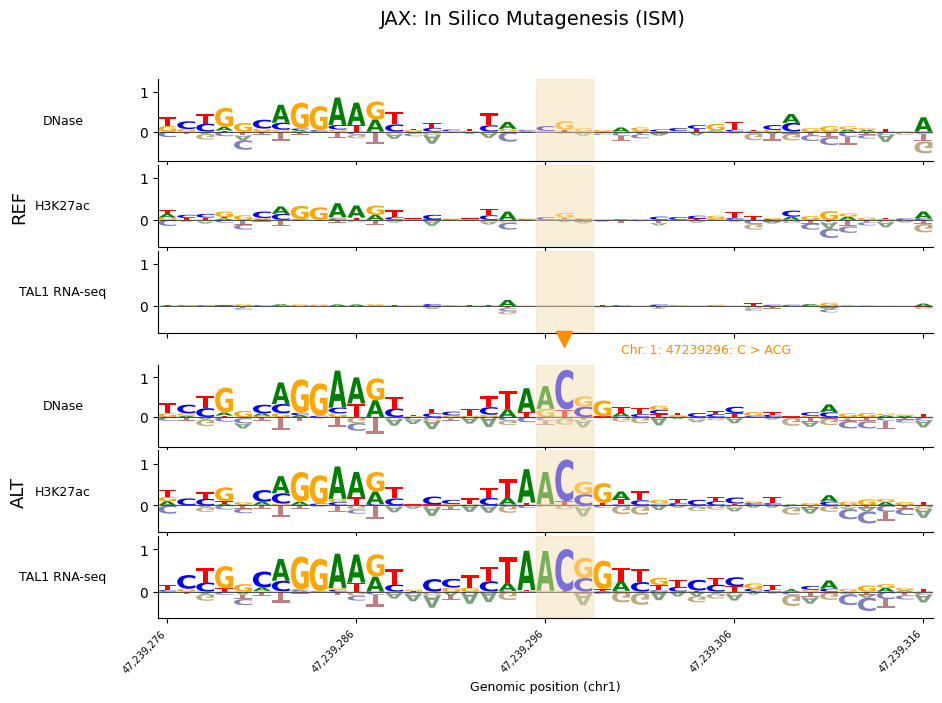

In [15]:
jax_ref_logos, jax_alt_logos = build_ism_logos(
    jax_ism_ref,
    jax_ism_alt,
    ref_seq_str,
    alt_seq_str,
    interval,
    TRACK_CONFIGS,
    CENTER_REL_REF,
    HALF_WINDOW,
    TAL1_GENE
)
jax_ism = plot_ism_logos(
    jax_ref_logos,
    jax_alt_logos,
    TRACK_CONFIGS,
    variant,
    HALF_WINDOW,
    title='JAX: In Silico Mutagenesis (ISM)',
    savepath='Fig6e_ism_jax.png',
)

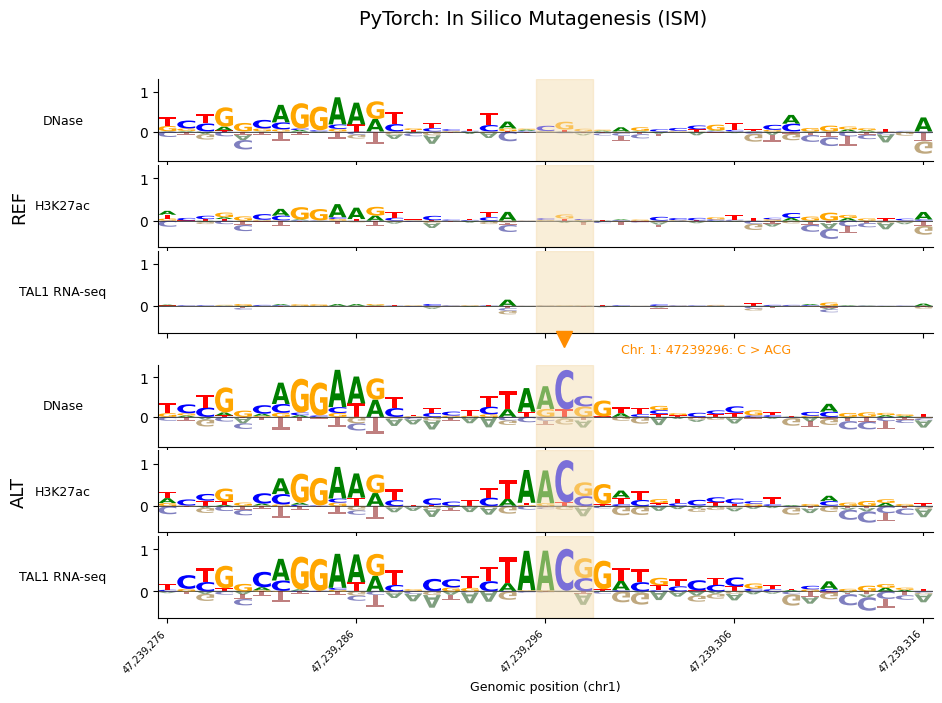

In [16]:
torch_ref_logos, torch_alt_logos = build_ism_logos(
    torch_ism_ref,
    torch_ism_alt,
    ref_seq,
    alt_seq,
    interval,
    TRACK_CONFIGS,
    CENTER_REL_REF,
    HALF_WINDOW,
    TAL1_GENE
)
torch_ism = plot_ism_logos(
    torch_ref_logos,
    torch_alt_logos,
    TRACK_CONFIGS,
    variant,
    HALF_WINDOW,
    title='PyTorch: In Silico Mutagenesis (ISM)',
    savepath='Fig6e_ism_torch.png',
)